In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.shape

(50000, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


## For NLP task we will handel the basic steps 
- Gathering of Data (Scaraping/APIs) ✅
- Cleaning 
    - lowercasing
    - removing leading and trailing spaces
    - remove html tags
    - remove urls
    - Expanding abbreviations
    - spelling correction
    - remove special chareacters
- Pre-processing
    - Tokenization
    - Stop-word Removal
    - Stemming
- EDA
    - Make Some Features (examples : Numbers of Words (number) , ... , ... )
    - common uniframs/bigrams/trigrams
- Text-Vectorization (Bag-of words , IdIdf , Wordwcc)
- Modeling
- Evaluation
- Deploy
- Monitering 

### Cleaning 

In [7]:
# do we have duplicates 
df.duplicated().sum() ## we have duplicates 

np.int64(418)

In [8]:
df = df.drop_duplicates()
df.shape ## 50,000 --> 49,582

(49582, 2)

In [9]:
# 1.Lower-Casing

df["review"] = df["review"].str.lower()  

In [10]:
df['review'][0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.<br /><br />it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />i would say the main appeal of the show is due to the fa

In [11]:
# 2. Stripping 

df["review"] = df["review"].str.strip()

In [12]:
# 3.remove html tags
import re 
def remove_html(data):
    data = re.sub(r'<.*?>' , '', data)
    return data

In [13]:
remove_html("""<h1>Welcome to My Website</h1><p>This is a simple paragraph of text on an HTML page.</p>""")

'Welcome to My WebsiteThis is a simple paragraph of text on an HTML page.'

In [14]:

df["review"] = df["review"].apply(remove_html)

In [15]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [16]:
# 4. remove URLS
# http://campusx.in www.campusx.in www.campusx.co.in

def remove_url(data):
    data=re.sub(r"https?://\S+|www\.\S+",'',data)
    return data

remove_url("http://campusx.in www.campusx.in www.campusx.co.in") ## http
remove_url("https://campusx.in www.campusx.in www.campusx.co.in") ## https

'  '

In [17]:
# wehere are the rows where are urls

df[df.review.str.contains(r"https?://\S+|www\.\S+")]["review"].shape  ## 194 rows have url in them 

(194,)

In [18]:
## removings them 

df["review"] = df["review"].apply(remove_url)

In [19]:
# 5. Expanding abbreviations

def remove_abb(data):
    data = re.sub(r"he's", "he is", data)
    data = re.sub(r"there's", "there is", data)
    data = re.sub(r"We're", "We are", data)
    data = re.sub(r"That's", "That is", data)
    data = re.sub(r"won't", "will not", data)
    data = re.sub(r"they're", "they are", data)
    data = re.sub(r"Can't", "Cannot", data)
    data = re.sub(r"wasn't", "was not", data)
    data = re.sub(r"don\x89Ûªt", "do not", data)
    data= re.sub(r"aren't", "are not", data)
    data = re.sub(r"isn't", "is not", data)
    data = re.sub(r"What's", "What is", data)
    data = re.sub(r"haven't", "have not", data)
    data = re.sub(r"hasn't", "has not", data)
    data = re.sub(r"There's", "There is", data)
    data = re.sub(r"He's", "He is", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"You're", "You are", data)
    data = re.sub(r"I'M", "I am", data)
    data = re.sub(r"shouldn't", "should not", data)
    data = re.sub(r"wouldn't", "would not", data)
    data = re.sub(r"i'm", "I am", data)
    data = re.sub(r"I\x89Ûªm", "I am", data)
    data = re.sub(r"I'm", "I am", data)
    data = re.sub(r"Isn't", "is not", data)
    data = re.sub(r"Here's", "Here is", data)
    data = re.sub(r"you've", "you have", data)
    data = re.sub(r"you\x89Ûªve", "you have", data)
    data = re.sub(r"we're", "we are", data)
    data = re.sub(r"what's", "what is", data)
    data = re.sub(r"couldn't", "could not", data)
    data = re.sub(r"we've", "we have", data)
    data = re.sub(r"it\x89Ûªs", "it is", data)
    data = re.sub(r"doesn\x89Ûªt", "does not", data)
    data = re.sub(r"It\x89Ûªs", "It is", data)
    data = re.sub(r"Here\x89Ûªs", "Here is", data)
    data = re.sub(r"who's", "who is", data)
    data = re.sub(r"I\x89Ûªve", "I have", data)
    data = re.sub(r"y'all", "you all", data)
    data = re.sub(r"can\x89Ûªt", "cannot", data)
    data = re.sub(r"would've", "would have", data)
    data = re.sub(r"it'll", "it will", data)
    data = re.sub(r"we'll", "we will", data)
    data = re.sub(r"wouldn\x89Ûªt", "would not", data)
    data = re.sub(r"We've", "We have", data)
    data = re.sub(r"he'll", "he will", data)
    data = re.sub(r"Y'all", "You all", data)
    data = re.sub(r"Weren't", "Were not", data)
    data = re.sub(r"Didn't", "Did not", data)
    data = re.sub(r"they'll", "they will", data)
    data = re.sub(r"they'd", "they would", data)
    data = re.sub(r"DON'T", "DO NOT", data)
    data = re.sub(r"That\x89Ûªs", "That is", data)
    data = re.sub(r"they've", "they have", data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"should've", "should have", data)
    data = re.sub(r"You\x89Ûªre", "You are", data)
    data = re.sub(r"where's", "where is", data)
    data = re.sub(r"Don\x89Ûªt", "Do not", data)
    data = re.sub(r"we'd", "we would", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"weren't", "were not", data)
    data = re.sub(r"They're", "They are", data)
    data = re.sub(r"Can\x89Ûªt", "Cannot", data)
    data = re.sub(r"you\x89Ûªll", "you will", data)
    data = re.sub(r"I\x89Ûªd", "I would", data)
    data = re.sub(r"let's", "let us", data)
    data = re.sub(r"it's", "it is", data)
    data = re.sub(r"can't", "cannot", data)
    data = re.sub(r"don't", "do not", data)
    data = re.sub(r"you're", "you are", data)
    data = re.sub(r"i've", "I have", data)
    data = re.sub(r"that's", "that is", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"doesn't", "does not",data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"didn't", "did not", data)
    data = re.sub(r"ain't", "am not", data)
    data = re.sub(r"you'll", "you will", data)
    data = re.sub(r"I've", "I have", data)
    data = re.sub(r"Don't", "do not", data)
    data = re.sub(r"I'll", "I will", data)
    data = re.sub(r"I'd", "I would", data)
    data = re.sub(r"Let's", "Let us", data)
    data = re.sub(r"you'd", "You would", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"Ain't", "am not", data)
    data = re.sub(r"Haven't", "Have not", data)
    data = re.sub(r"Could've", "Could have", data)
    data = re.sub(r"youve", "you have", data)  
    data = re.sub(r"donå«t", "do not", data)
    
    return data

In [20]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [21]:
df["review"] = df["review"].apply(remove_abb)

In [22]:
df.head()


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there is a family where a little boy...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [23]:
from textblob import TextBlob

text = "hi can drie at nigt"
TextBlob(text).correct().string

'hi can drive at night'

In [24]:
def spell_correction(text):
    return TextBlob(text).correct().string

In [25]:
# 5. Spelling Correction 
# df["review"] = df["review"].apply(spell_correction)   ### Too Much Load on the CPU 

In [26]:
# 6. Remove Puntuations
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [27]:
def remove_punc(text):
    import string
    for i in string.punctuation :
        if i in text : 
            text = text.replace(i , "")
    return text

In [28]:
df["review"] = df["review"].apply(remove_punc)  

In [29]:
# 7. Remove The Special Chareacter 
df["review"] = df["review"].str.replace(r"[^\w\s]","")

In [30]:
df.sample(5)

,review,sentiment
42330,featured in 1955s the cobweb is an all star ca...,negative
25078,i loved this film seen this evening on a movie...,positive
37446,this movie was a low point for both jason roba...,negative
16817,i usually comment only on movies that i like f...,negative
42619,when i was driving home after work i bought so...,negative


### Pre-Processing 

In [31]:
from nltk.tokenize import word_tokenize

In [32]:
# tokenization 
df["tokenized_review"] = df.review.apply(word_tokenize)

In [33]:
# stop word removal
from nltk.corpus import stopwords

len(stopwords.words("english"))

198

In [34]:
def remove_stop_words(text):
    L=[]
    for word in text : 
        if word not in stopwords.words("english") : 
            L.append(word)

    return L

In [35]:
# df['tokenized_review'] = df["tokenized_review"].apply(remove_stop_words)  ## tomuch CPU consumtion so topped 

In [36]:
df.head()

,review,sentiment,tokenized_review
0,one of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production the filming tech...,positive,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically there is a family where a little boy...,negative,"[basically, there, is, a, family, where, a, li..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, in, the, time, of, mon..."


- `df['tokenized_review'] = df["tokenized_review"].apply(remove_stop_words)  ## tomuch CPU consumtion so topped` after this line we need to update the review column with out stop words like this `df["review"] = df["tokenized_review"].apply(lambda x : " ".join(x) )`

### EDA

In [37]:
df['char_len']= df['review'].str.len()
df.head(2)

,review,sentiment,tokenized_review,char_len
0,one of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione...",1674
1,a wonderful little production the filming tech...,positive,"[a, wonderful, little, production, the, filmin...",936


In [38]:
df['word_len']= df['tokenized_review'].str.len()
df.head(2)

,review,sentiment,tokenized_review,char_len,word_len
0,one of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione...",1674,305
1,a wonderful little production the filming tech...,positive,"[a, wonderful, little, production, the, filmin...",936,156


In [39]:
import seaborn as sns 

/tmp/ipykernel_58/1369747843.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["char_len"])


<Axes: xlabel='char_len', ylabel='Density'>

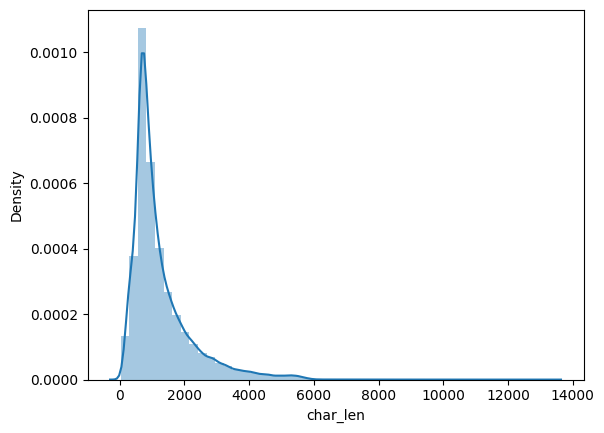

In [40]:
sns.distplot(df["char_len"])

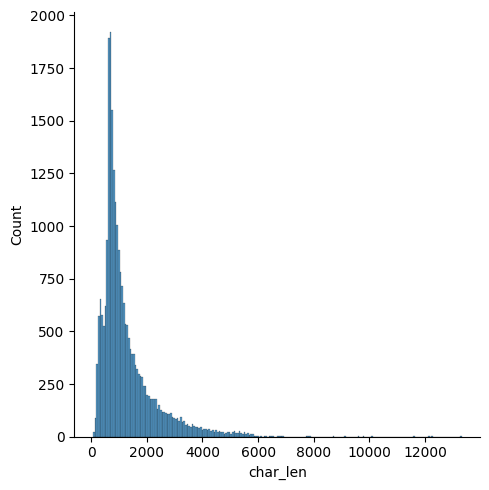

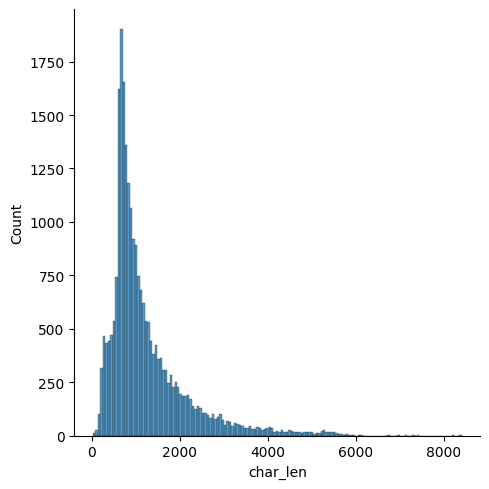

In [41]:
sns.displot(df[df["sentiment"] =="positive"]["char_len"])
sns.displot(df[df["sentiment"] =="negative"]["char_len"])


- if the cureves are **differnt** then the feature is a **good** indicator
- if the cureves are same then the feature is a bad indicator
-  here char_len is kinf of not a good indicator 

##### you can find the bi grams and tri grams for the tokenized_review column and see if there are some bi grams which mainly appear for +ve revirew or +ve review --> CPU overhead issue


##### Word Cloud

(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

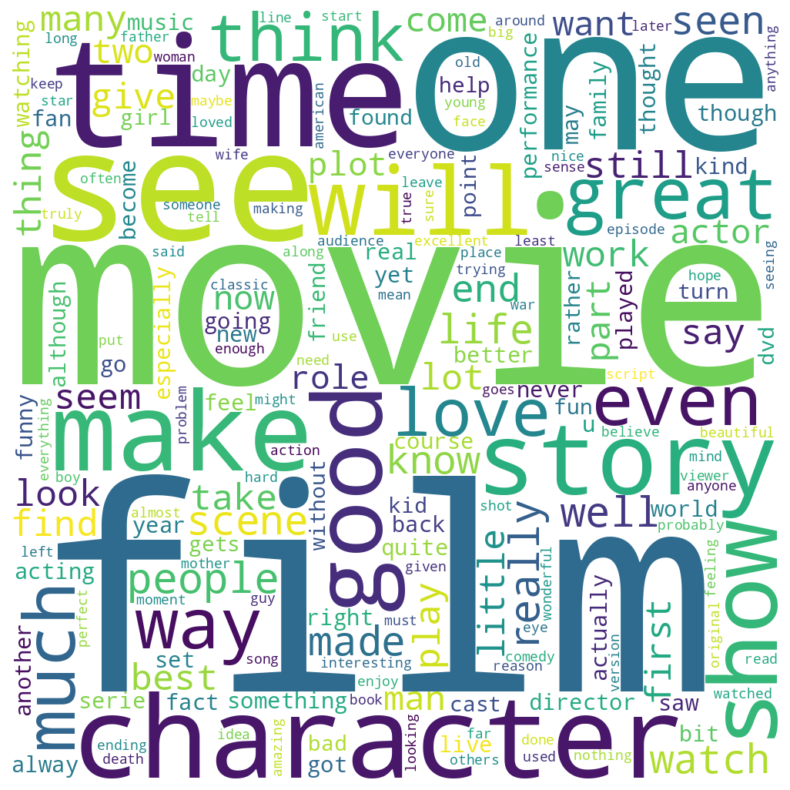

In [42]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10)) # for positive reviews words
wc = WordCloud(width=1000,height=1000,background_color='white',min_font_size=10).generate(' '.join(df[df.sentiment == "positive"]["review"]))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')

(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

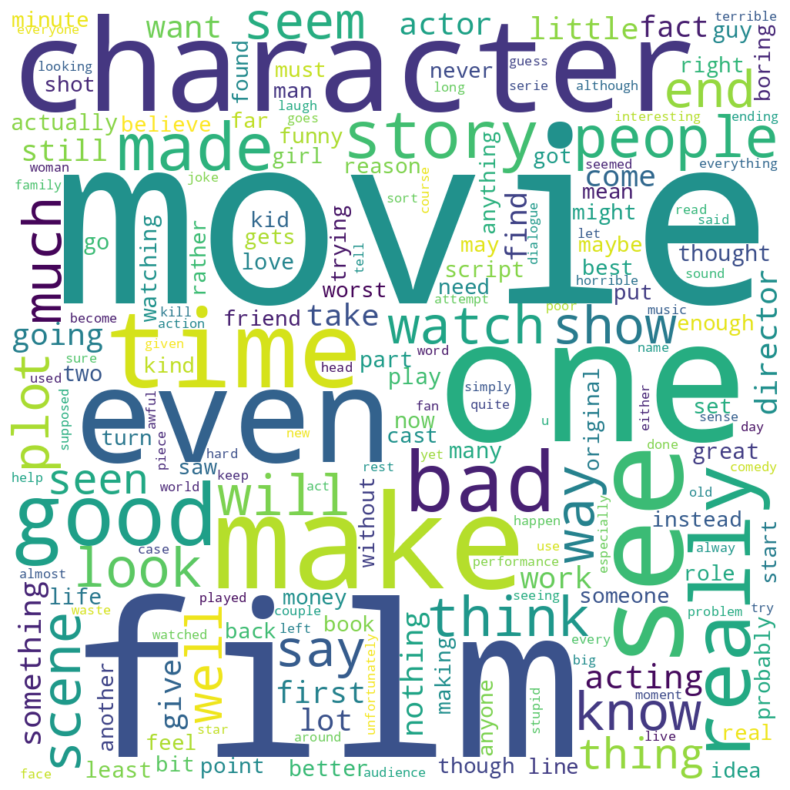

In [43]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10)) # for negative reviews words
wc = WordCloud(width=1000,height=1000,background_color='white',min_font_size=10).generate(' '.join(df[df.sentiment == "negative"]["review"]))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')